# Stellar Magnitude Explorer - Histograms & Colour-Magnitude Diagram


## Objective
- Visualize the distribution of G-band magnitudes, BP-RP colour indices and parallax.
- Construct a Colour-Magnitude Diagram (CMD) and Hertzsprung-Russell Diagram to identify stellar populations.

## Why this matters
- __Magnitude histogram__ shows sample completeness and the luminosity function.
- __Colour index histogram__ reveals the dominant stellar types (e.g., peak near `bp_rp` ~ 0.8 for solar-type stars).
- __Parallax histogram__ shows us where our sources are mostly concentrated and their proximity.
- __CMD and HR Diagrams__ are a fundamental tool in astrophysics which is used to seperate stars by evolutionary stage.

## Dataset
- Input: `sources_with_galactic_coord_random.fits` (random sample, 10000 sources)
- Columns: `phot_g_mean_mag` (G magnitude), `bp_rp` (colour index)

## Goals for Today
- Load the random sample
- Plot histogram of `phot_g_mean_mag` (with bins and labels)
- Plot histogram of `bp_rp` (remove masked values)
- Plot histogram of `parallax`
- Calculate the Absolute Magnitude for each source using Pogson's relationship
- Create Colour-Magnitude Diagrams and Hertzsprung-Russe Diagrams: `bp_rp` (x) vs `phot_g_mean_mag` (y, inverted) and `bp_rp` vs `abs_mag`
- Write interpretation: what do these diagrams tell me about the sources

## Checkpoint
- Magnitude histogram plotted
- Colour index histogram plotted (excluding missing values)
- Parallax histogram plotted
- Colour-Magnitude and Hertzsprung-Russell diagrams plotted with y-axis inverted (brighter stars at top)
- Brief interpretation of each figure

## Code 
### 1. Setup and Loading

In [4]:
from astropy.visualization import hist
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np

In [5]:
table = Table.read("../../data/sources_with_galactic_coord_random.fits")
table.info()

<Table length=10000>
      name       dtype  unit    class     n_bad
--------------- ------- ---- ------------ -----
      source_id   int64            Column     0
             ra float64  deg       Column     0
            dec float64  deg       Column     0
          gal_l float64  deg       Column     0
          gal_b float64  deg       Column     0
       parallax float64  mas       Column     0
phot_g_mean_mag float32  mag       Column     0
          bp_rp float32  mag MaskedColumn    12


We will using the `bp_rp` column for plotting our color index histogram and CMDs but it appears that there is missing data (hence represented by the `MaskedColumn` class). The approach we use is filling missing values with NaN and drop.

In [ ]:
bp_rp_filled = table['bp_rp'].filled(np.nan)
bp_rp_clean = bp_rp_filled[~np.isnan(bp_rp_filled)]

10000
10000


Now we can use `bp_rp_clean` for our histogram and CMD plots instead of the `bp_rp` column.

### 2. Histograms

Now we can plot our histograms to observe distribution of sources based on magnitude, colour indices and parallax to confirm if there is a skewed tendency. We will use both a fixed number of bins and the `block` fitness function for our histograms.

#### 2.1 G-band Magnitude (`phot_g_mean_mag`) Histogram

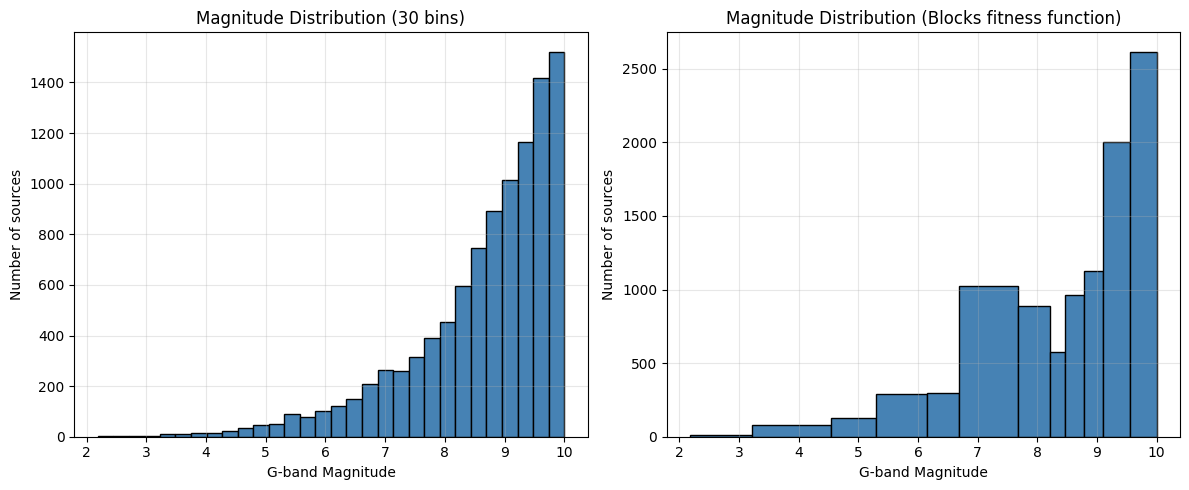

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
hist(table['phot_g_mean_mag'], bins=30, ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Magnitude Distribution (30 bins)')
ax1.set_xlabel('G-band Magnitude')
ax1.set_ylabel('Number of sources')
ax1.grid(True, alpha=0.3)

hist(table['phot_g_mean_mag'], bins='blocks', ax=ax2, color='steelblue', edgecolor='black')
ax2.set_title('Magnitude Distribution (Blocks fitness function)')
ax2.set_xlabel('G-band Magnitude')
ax2.set_ylabel('Number of sources')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

#### 2.2 Colour Index (`bp_rp`) Histogram

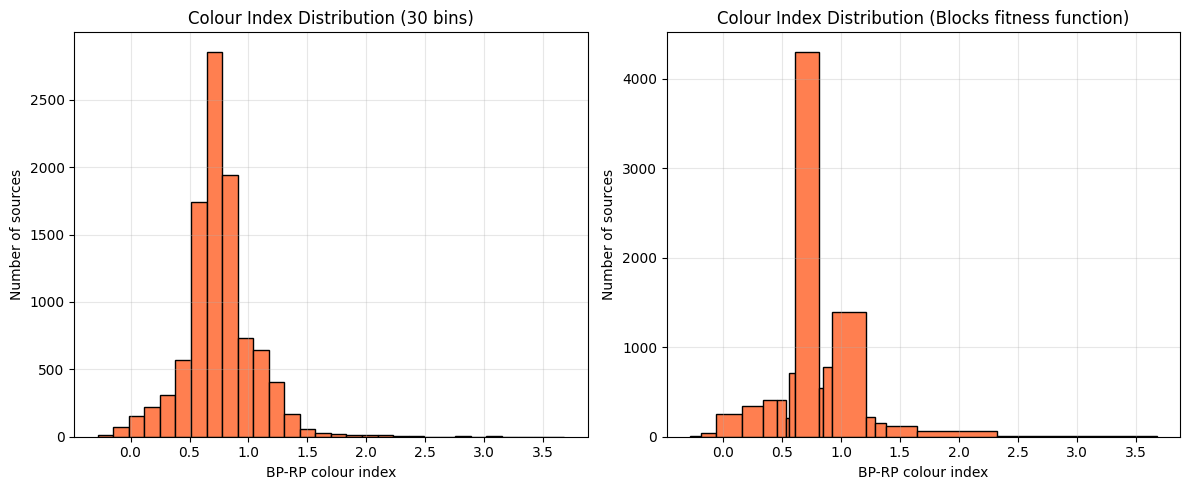

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
hist(bp_rp_clean, bins=30, ax=ax1, color='coral', edgecolor='black')
ax1.set_title('Colour Index Distribution (30 bins)')
ax1.set_xlabel('BP-RP colour index')
ax1.set_ylabel('Number of sources')
ax1.grid(True, alpha=0.3)


hist(bp_rp_clean, bins='blocks', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Colour Index Distribution (Blocks fitness function)')
ax2.set_xlabel('BP-RP colour index')
ax2.set_ylabel('Number of sources')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.3 Parallax (`parallax`) Histogram

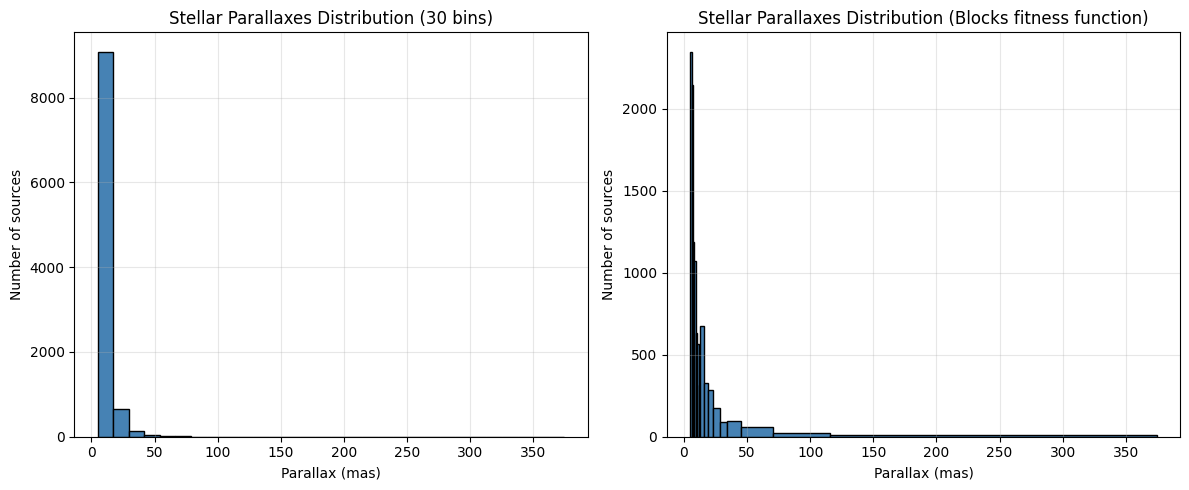

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
hist(table['parallax'], bins=30, ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Stellar Parallaxes Distribution (30 bins)')
ax1.set_xlabel('Parallax (mas)')
ax1.set_ylabel('Number of sources')
ax1.grid(True, alpha=0.3)

hist(table['parallax'], bins='blocks', ax=ax2, color='steelblue', edgecolor='black')
ax2.set_title('Stellar Parallaxes Distribution (Blocks fitness function)')
ax2.set_xlabel('Parallax (mas)')
ax2.set_ylabel('Number of sources')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Colour-Magnitude Diagrams

In this section, we plot CMDs for both the apparent magnitude _m_ (`phot_g_mean_mag`) and absolute magnitude _M_. We obtain _M_ by applying the Pogson's relation for distance modulus:

$M = m - 5log_{10}(d) + 5$                                     

where we substitute $d$ with $\frac{1000}{\varpi}$ and $\varpi$ represents parallax (`parallax`) in milliarcseconds. Therefore, we have:

$M = m - 5log_{10}(\frac{1000}{\varpi}) + 5$

$M = m - 5(3 - log_{10}(\varpi)) + 5$

$M = m - 15 + 5log_{10}(\varpi) + 5$

$M = m + 5log_{10}(\varpi) - 10$

We will use the final relation to calculate the absolute magnitude for each source and add a column `abs_mag` to the table. However, we should keep in mind that Gaia data is likely to have uncertainties and that the calculated values do not account for __interstellar extinction__.

In [34]:
table['abs_mag'] = table['phot_g_mean_mag'] + (5 * np.log10(table['parallax'])) - 10
table.info()

<Table length=10000>
      name       dtype  unit    class     n_bad
--------------- ------- ---- ------------ -----
      source_id   int64            Column     0
             ra float64  deg       Column     0
            dec float64  deg       Column     0
          gal_l float64  deg       Column     0
          gal_b float64  deg       Column     0
       parallax float64  mas       Column     0
phot_g_mean_mag float32  mag       Column     0
          bp_rp float32  mag MaskedColumn    12
        abs_mag float64  mag       Column     0


#### 3.1. Colour-Magnitude Diagrams (Apparent Magnitude)

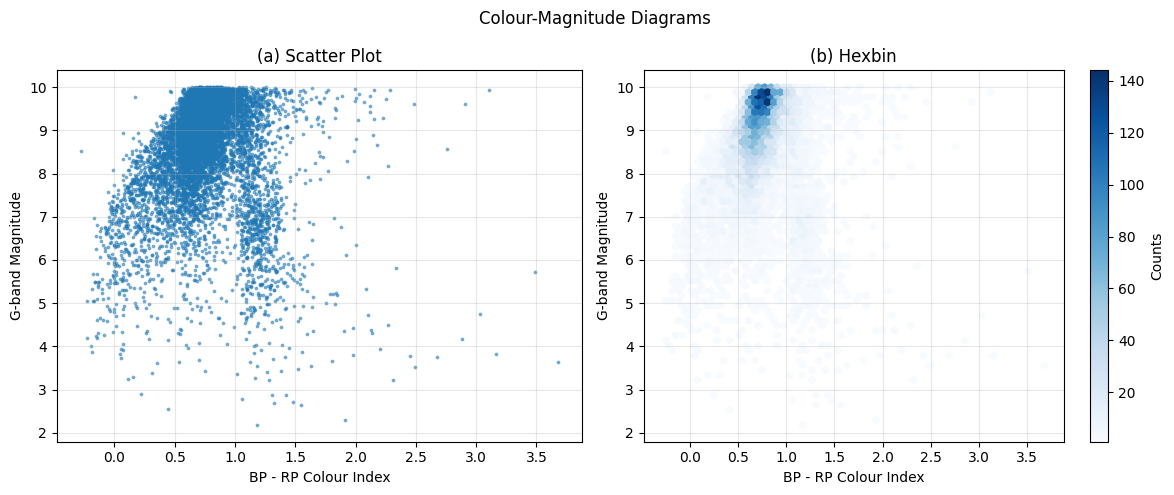

In [46]:
# Remove rows with missing bp_rp

mask = ~table['bp_rp'].mask
bp_rp_clean = table['bp_rp'][mask]
mag_clean = table['phot_g_mean_mag'][mask]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(bp_rp_clean, mag_clean, s=3, alpha=0.5)
ax1.set_xlabel('BP - RP Colour Index')
ax1.set_ylabel('G-band Magnitude')
ax1.set_title('(a) Scatter Plot')
fig.gca().invert_yaxis()
ax1.grid(True, alpha=0.3)

hb2 = ax2.hexbin(bp_rp_clean, mag_clean, gridsize=60, cmap='Blues', mincnt=1)
fig.colorbar(hb2, ax=ax2, label='Counts')
ax2.set_xlabel('BP - RP Colour Index')
ax2.set_ylabel('G-band Magnitude')
ax2.set_title('(b) Hexbin')
fig.gca().invert_yaxis()
ax2.grid(True, alpha=0.3)


plt.suptitle("Colour-Magnitude Diagrams")
plt.tight_layout()
plt.show()



#### 3.1. Colour-Magnitude Diagrams (Absolute Magnitude)

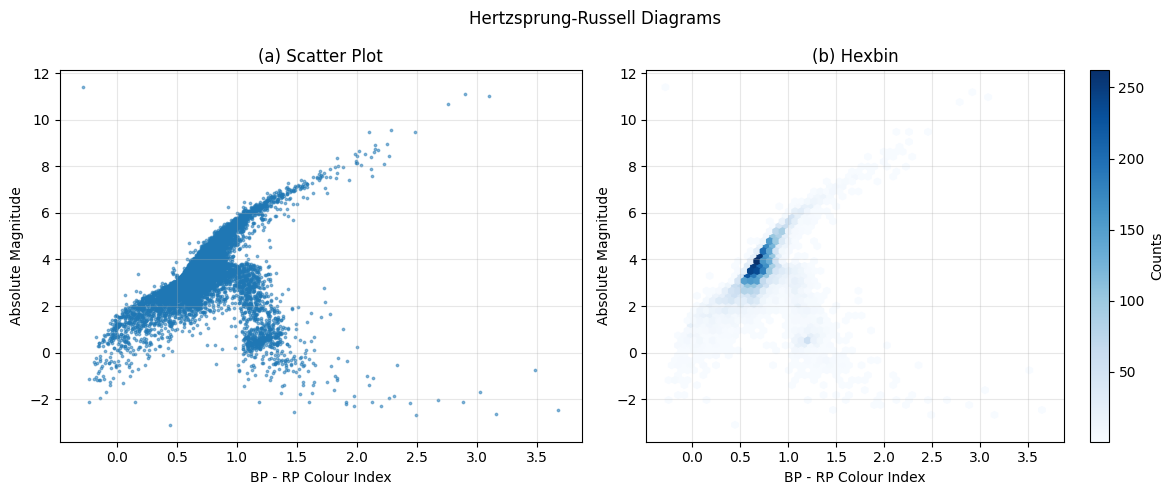

In [45]:
abs_mag_clean = table['abs_mag'][mask]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(bp_rp_clean, abs_mag_clean, s=3, alpha=0.5)
ax1.set_xlabel('BP - RP Colour Index')
ax1.set_ylabel('Absolute Magnitude')
ax1.set_title('(a) Scatter Plot')
fig.gca().invert_yaxis()
ax1.grid(True, alpha=0.3)

hb2 = ax2.hexbin(bp_rp_clean, abs_mag_clean, gridsize=60, cmap='Blues', mincnt=1)
fig.colorbar(hb2, ax=ax2, label='Counts')
ax2.set_xlabel('BP - RP Colour Index')
ax2.set_ylabel('Absolute Magnitude')
ax2.set_title('(b) Hexbin')
fig.gca().invert_yaxis()
ax2.grid(True, alpha=0.3)

plt.suptitle("Hertzsprung-Russell Diagrams")
plt.tight_layout()
plt.show()

